In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
stockk="AAPL"
# data = yf.download(stock, start="2020-01-01",end="2026-03-08")
data = yf.download(stockk,period="max")

print(data.head())                
print(data.tail())


[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
1980-12-12  0.098298  0.098725  0.098298  0.098298  469033600
1980-12-15  0.093169  0.093597  0.093169  0.093597  175884800
1980-12-16  0.086331  0.086758  0.086331  0.086758  105728000
1980-12-17  0.088468  0.088895  0.088468  0.088468   86441600
1980-12-18  0.091032  0.091460  0.091032  0.091032   73449600
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-03-02  264.720001  266.529999  260.200012  262.410004  41827900
2026-03-03  263.750000  265.559998  260.130005  263.480011  38568900
2026-03-04  262.519989  266.149994  261.420013  264.649994  39803100
2026-03-05  260.290009  261.559998  257.250000  260.790009  49658600
2026-03-06  257.45999

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11399 entries, 1980-12-12 to 2026-03-06
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   11399 non-null  float64
 1   (High, AAPL)    11399 non-null  float64
 2   (Low, AAPL)     11399 non-null  float64
 3   (Open, AAPL)    11399 non-null  float64
 4   (Volume, AAPL)  11399 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 534.3 KB


In [10]:
# Daily return
data['Return'] = data['Close'].pct_change()

# Moving averages
data['MA10'] = data['Close'].rolling(10).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# Price change
data['Price_Change'] = data['Close'] - data['Open']

# Volatility
data['Volatility'] = data['High'] - data['Low']

In [11]:
# STEP 3: CREATE TARGET VARIABLE

# 1 = price goes UP tomorrow
# 0 = price goes DOWN tomorrow
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

data = data.dropna()

In [12]:
# STEP 4: SELECT FEATURES
features = ['Return', 'MA10', 'MA50', 'Price_Change', 'Volatility']

X = data[features]
y = data['Target']

In [13]:
# STEP 5: SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
# STEP 6: TRAIN MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
# STEP 7: MODEL ACCURACY
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)


Model Accuracy: 0.4814977973568282


In [21]:
latest_data = X.iloc[-1].values.reshape(1, -1)

prediction = model.predict(latest_data)

latest_close = data['Close'].iloc[-1].values[0]

latest_date = data.index[-1]

print("\nLatest Date:", latest_date.date())
print("Latest Closing Price:", round(latest_close,2))

print("\nPrediction for Next Trading Day:")

if prediction[0] == 1:
    print("📈 Stock Price will go UP")
else:
    print("📉 Stock Price will go DOWN")


Latest Date: 2026-03-06
Latest Closing Price: 257.46

Prediction for Next Trading Day:
📉 Stock Price will go DOWN


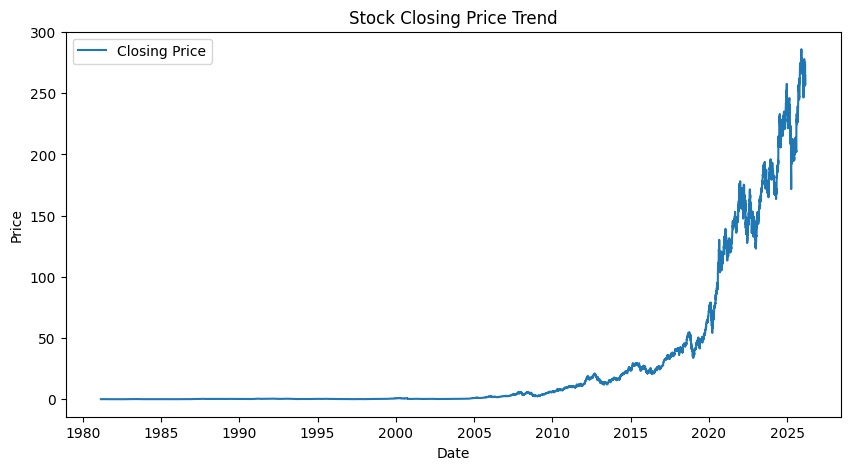

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(data.index, data['Close'], label="Closing Price")

plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

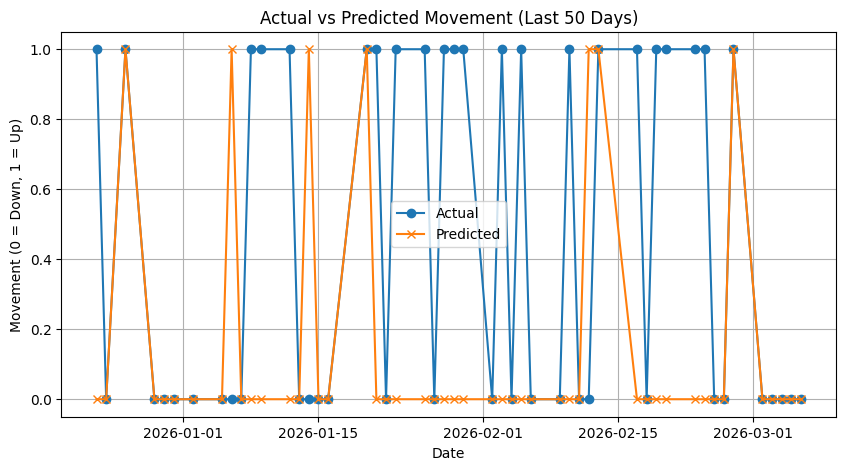

In [26]:
import matplotlib.pyplot as plt

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
}, index=y_test.index)

last = pred_df.tail(50)

plt.figure(figsize=(10,5))

plt.plot(last.index, last["Actual"], marker='o', label="Actual")
plt.plot(last.index, last["Predicted"], marker='x', label="Predicted")

plt.title("Actual vs Predicted Movement (Last 50 Days)")
plt.xlabel("Date")
plt.ylabel("Movement (0 = Down, 1 = Up)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

st.title("📊 Stock Price Movement Predictor")

# User input
ticker = st.text_input("Enter Stock Ticker", "AAPL")

# Download stock data
stock = yf.download(ticker, period="5y")

# Feature Engineering
stock['Return'] = stock['Close'].pct_change()
stock['MA10'] = stock['Close'].rolling(10).mean()
stock['MA50'] = stock['Close'].rolling(50).mean()
stock['Price_Change'] = stock['Close'] - stock['Open']
stock['Volatility'] = stock['High'] - stock['Low']

# Target
stock['Target'] = np.where(stock['Close'].shift(-1) > stock['Close'], 1, 0)

stock = stock.dropna()

# Features
features = ['Return','MA10','MA50','Price_Change','Volatility']

X = stock[features]
y = stock['Target']

# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

# Model
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train,y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)

# Latest prediction
latest_data = X.iloc[-1].values.reshape(1,-1)
prediction = model.predict(latest_data)

latest_close = stock['Close'].iloc[-1]

# Display metrics
st.subheader("Latest Stock Information")

st.write("Latest Closing Price:", round(float(latest_close),2))
st.write("Model Accuracy:", round(accuracy,2))

if prediction[0] == 1:
    st.success("Prediction: Price will go UP 📈")
else:
    st.error("Prediction: Price will go DOWN 📉")

# Stock price graph
st.subheader("Stock Closing Price Chart")

fig, ax = plt.subplots()

ax.plot(stock.index,stock['Close'])

ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.set_title("Closing Price Trend")

st.pyplot(fig)